# Deployment Notebook: IMDb Sentiment Model to Hugging Face Spaces

This notebook assumes you already trained and saved your model locally in this folder:

```text
saved_imdb_sentiment_model
```

This notebook will:

1. Load and test the saved local model.
2. Log in to Hugging Face.
3. Upload the model to Hugging Face Model Hub.
4. Create a Gradio app.
5. Upload the app to Hugging Face Spaces.

## 1. Install required packages

Run this cell first. After installation, restart the kernel/runtime if your notebook asks you to.

In [4]:
!pip install -q --upgrade transformers torch gradio "huggingface-hub>=1.2.0,<2.0"


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


## 2. Set your project information

In [5]:
HF_USERNAME = "choupeiyuan"

MODEL_REPO_NAME = "imdb-sentiment-model"
SPACE_REPO_NAME = "imdb-sentiment-space"

MODEL_REPO_ID = f"{HF_USERNAME}/{MODEL_REPO_NAME}"
SPACE_REPO_ID = f"{HF_USERNAME}/{SPACE_REPO_NAME}"

LOCAL_MODEL_DIR = "saved_imdb_sentiment_model"

print("Model repo:", MODEL_REPO_ID)
print("Space repo:", SPACE_REPO_ID)
print("Local model folder:", LOCAL_MODEL_DIR)

Model repo: choupeiyuan/imdb-sentiment-model
Space repo: choupeiyuan/imdb-sentiment-space
Local model folder: saved_imdb_sentiment_model


## 3. Load and test the saved model locally

This step verifies that your model was saved correctly before uploading it.

In [6]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline

model_path = "saved_imdb_sentiment_model"

tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)

classifier = pipeline(
    "sentiment-analysis",
    model=model,
    tokenizer=tokenizer)

test_texts = [
    "This movie was surprisingly good. I really enjoyed the story.",
    "The plot was boring and the acting was terrible.",
    "The movie started slowly, but the ending was excellent.",
]

for text in test_texts:
    print(text)
    print(classifier(text))
    print()

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

This movie was surprisingly good. I really enjoyed the story.
[{'label': 'POSITIVE', 'score': 0.9953816533088684}]

The plot was boring and the acting was terrible.
[{'label': 'NEGATIVE', 'score': 0.9956445693969727}]

The movie started slowly, but the ending was excellent.
[{'label': 'POSITIVE', 'score': 0.9902083873748779}]



## 5. Log in to Hugging Face

You need a Hugging Face **Access Token** with **write** permission.

When the login box appears, paste your token.

In [7]:
from huggingface_hub import notebook_login

notebook_login()

### Note: 

To log in Hugging Face, you may require to copy a token from your hugging face tokens page. If you don't have a token, you can create one following below steps: 

1. Go to Hugging Face and log in.
2. Click your profile picture in the top-right corner.
3. Go to Settings.
4. Click Access Tokens.
5. Click New token.
6. Give it a name, for example: imdb-deployment-token
7. Choose permission:Write
Use Write because you want to upload your fine-tuned model to Hugging Face Hub. Hugging Face’s official docs say a token with write access is needed if you want to upload or modify content.
8. Click Generate token.
9. Copy the token immediately.

## 6. Upload the model to Hugging Face Model Hub

This uploads the contents of `saved_imdb_sentiment_model` to your Hugging Face model repository.

In [8]:
from huggingface_hub import create_repo, upload_folder
#MODEL_REPO_NAME = "imdb-sentiment-model"

create_repo(
    repo_id=MODEL_REPO_ID,
    repo_type="model",
    exist_ok=True,
)

upload_folder(
    folder_path=LOCAL_MODEL_DIR,
    repo_id=MODEL_REPO_ID,
    repo_type="model",
)

print(f"Model uploaded to: https://huggingface.co/{MODEL_REPO_ID}")

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Model uploaded to: https://huggingface.co/choupeiyuan/imdb-sentiment-model


Now if you check your Hugging Face Profile, you found the model has been there. 
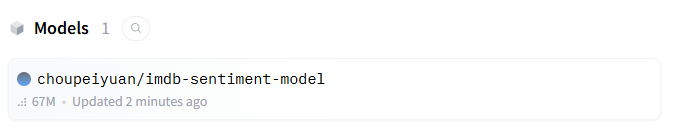

## 7. Test loading the model from Hugging Face Hub

This verifies that the uploaded model can be loaded from the internet.

In [9]:
hub_classifier = pipeline(
    "sentiment-analysis",
    model=MODEL_REPO_ID,
    tokenizer=MODEL_REPO_ID,
)

hub_classifier("This film was not perfect, but I still liked it.")


config.json:   0%|          | 0.00/735 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/1.20k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

[{'label': 'POSITIVE', 'score': 0.9952810406684875}]